### Data Preprocessing, add tatical features.

In [8]:
import pandas as pd
from src.data_pipeline.feature_engineering import main_data_pipeline
import os
from src.data_pipeline.clean import main_clean_pipeline

BASE_DIR = "./sample_data"

# ------------------------------------------
tournament_csv_path = os.path.join(BASE_DIR, "tournament.csv")
match_csv_path = os.path.join(BASE_DIR, "match.csv")
set_csv_path = os.path.join(BASE_DIR, "set.csv")
rally_csv_path = os.path.join(BASE_DIR, "rally.csv")
shot_csv_path = os.path.join(BASE_DIR, "shot.csv")

# ------------------------------------------
# Keep or remove for columns
# ------------------------------------------
tournament_cols_to_keep = ['tournament_id', 'level']
match_cols_to_keep = ['match_id', 'event','tournament_id','duration','set_count']
shot_cols_to_remove = ['time', 'start_frame_num', 'end_frame_num', 'set_num', 'current_win_score', 
                       'current_lose_score', 'lose_reason', 'score_team']
rally_cols_to_remove = ['start_frame', 'end_frame', 'comment', 'rally_video_check', 'score_reason','shot_count']


# Tournament
tournament_data = pd.read_csv(tournament_csv_path)
tournament_cols_to_remove = tournament_data.columns.difference(tournament_cols_to_keep).tolist()
tournament_data = tournament_data.drop(columns=tournament_cols_to_remove, errors='ignore')
tournament_data['level'] = tournament_data['level'].astype(str).str.replace('Super ', '', case=False).str.strip()

# Match
match_data = pd.read_csv(match_csv_path)
match_data['match_id'] = pd.to_numeric(match_data['match_id'], errors='coerce').fillna(0).astype('Int64')
match_data['event'] = pd.to_numeric(match_data['event'], errors='coerce').fillna(0).astype(int)
match_cols_to_remove = match_data.columns.difference(match_cols_to_keep).tolist()
match_data = match_data.drop(columns=match_cols_to_remove, errors='ignore')

# Set
set_data = pd.read_csv(set_csv_path)
set_data['match_id'] = pd.to_numeric(set_data['match_id'], errors='coerce').astype('Int64')

# Rally
rally_data = pd.read_csv(rally_csv_path)
rally_data = rally_data.drop(columns=rally_cols_to_remove, errors='ignore')

# Shot
shot_data = pd.read_csv(shot_csv_path)
shot_data = shot_data.drop(columns=shot_cols_to_remove, errors='ignore')
shot_data = main_clean_pipeline(shot_data)

# Merge
df_match_rally_shot = pd.merge(
        left=shot_data,
        right=rally_data,
        on='rally_id', 
        how='left'     
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=set_data,
        on='set_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=match_data,
        on='match_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )

full_df = main_data_pipeline(df_match_rally_shot)

print("(rows, columns):", full_df.shape)
print("Effective feature：\n", full_df.columns.tolist())
display(full_df.head(10))
OUTPUT_FILE = os.path.join(BASE_DIR, "df_cleaned_with_feature.csv")
full_df.to_csv(OUTPUT_FILE, index=False)


[Start Data Clean]...

--- Data Clean Result ---
Origin 662 rows
Remove 6 rows (coordinate outlier/unclassified/hit_height=0/Error Case)
Final 656 rows
--- remove result ---
Origin 656 rows。
5 rally of Exception
Remove 26 rows。
Final 630 rows。

[Data Clean Finished]

--- Clean return height ---

--- 球種映射完成 ---
最終分類結果:
ball_type
網前小球    182
挑球      111
平球       99
推撲球      74
殺球       70
發短球      65
切球       25
長球        2
發長球       2
Name: count, dtype: int64

--- 1-16 blocks result---
Hitting_Zone
8     240
7      81
4      76
6      71
5      52
9      48
3      44
2      16
13      1
1       1
Name: count, dtype: int64

--- Partner Angle Bin result ---
Angle_Bin
0    120
1     66
2     69
3    143
4    232
Name: count, dtype: int64

--- add center coverage and formation ---

--- Ball Height Direction result ---
ball_up_down
0    240
1    195
2    195
Name: count, dtype: int64

--- Final data validation (first few rows) ---
   shot_id  player ball_type Hitting_Zone  Partner_Angle  A

,shot_id,rally_id,shot_num,player,ball_type,backhand,player_A_x,player_A_y,player_B_x,player_B_y,...,shots_to_end,is_defense_failure,player_formation,next_rally_id,next_winner_mid_cover,next_loser_mid_cover,is_reaction_cover,match_Winner_AAI,match_Loser_AAI,ball_up_down
0,1,1,1,5,發短球,1,28.639847,94.300792,31.751217,113.677100,...,6,False,Attack,1.0,True,True,True,NaN,0.064047,0
1,2,1,2,7,推撲球,1,34.001378,88.407620,32.780770,114.213560,...,5,False,Attack,1.0,True,True,True,0.342563,NaN,0
2,3,1,3,6,挑球,1,36.690095,87.092290,36.825915,111.609023,...,4,False,Attack,1.0,True,True,True,NaN,0.013322,1
3,4,1,4,8,殺球,0,24.759652,109.455966,48.761037,122.480082,...,3,False,Attack,1.0,True,True,True,0.597411,NaN,2
4,5,1,5,6,平球,1,24.160234,111.525887,46.772711,118.061801,...,2,True,Defense,1.0,False,True,False,NaN,0.769209,1
5,6,1,6,7,推撲球,0,24.894581,115.227577,46.021033,119.147169,...,1,False,Attack,1.0,False,True,True,0.313007,NaN,2
6,7,1,7,6,平球,1,23.988683,114.688232,45.905338,119.146436,...,0,False,Defense,2.0,True,True,NaN,NaN,0.617746,0
7,8,2,1,8,發短球,1,30.606006,111.047223,41.950872,93.466893,...,13,False,Attack,2.0,True,True,True,0.372578,NaN,0
8,9,2,2,6,網前小球,0,30.711310,108.468965,40.302603,86.235682,...,12,False,Attack,2.0,True,True,True,NaN,0.204983,0
9,10,2,3,8,挑球,0,30.268870,112.088710,30.020094,83.111510,...,11,False,Defense,2.0,True,True,True,0.249663,NaN,1


In [9]:
full_df_path = os.path.join(BASE_DIR, "df_cleaned_with_feature.csv")
full_df = pd.read_csv(full_df_path)

Successfully loaded data, initial number of events: 630
Filtered out Angle=-404.0 and invalid rows, final number of valid shots: 562

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Defensive Shot    0.7
Offensive Shot    0.3
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Zone
Backcourt    0.20
Forecourt    0.17
Midcourt     0.63
Name: Count, dtype: float64
--------------------



c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


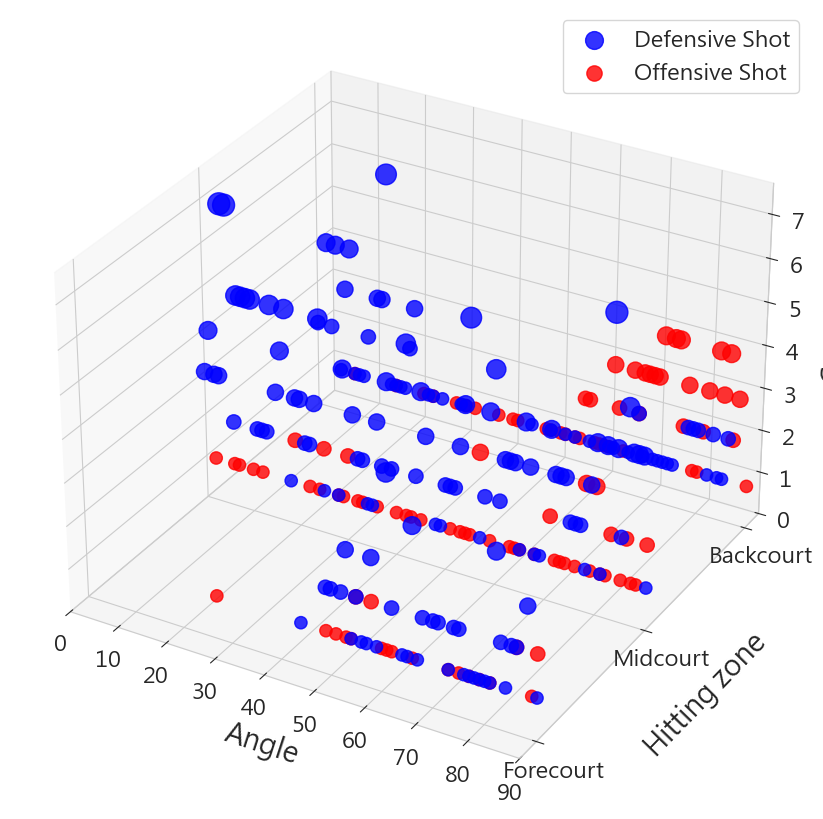

c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df_agg.groupby(['Angle_Group', 'ShotType'])['Count'].sum().unstack(fill_value=0)


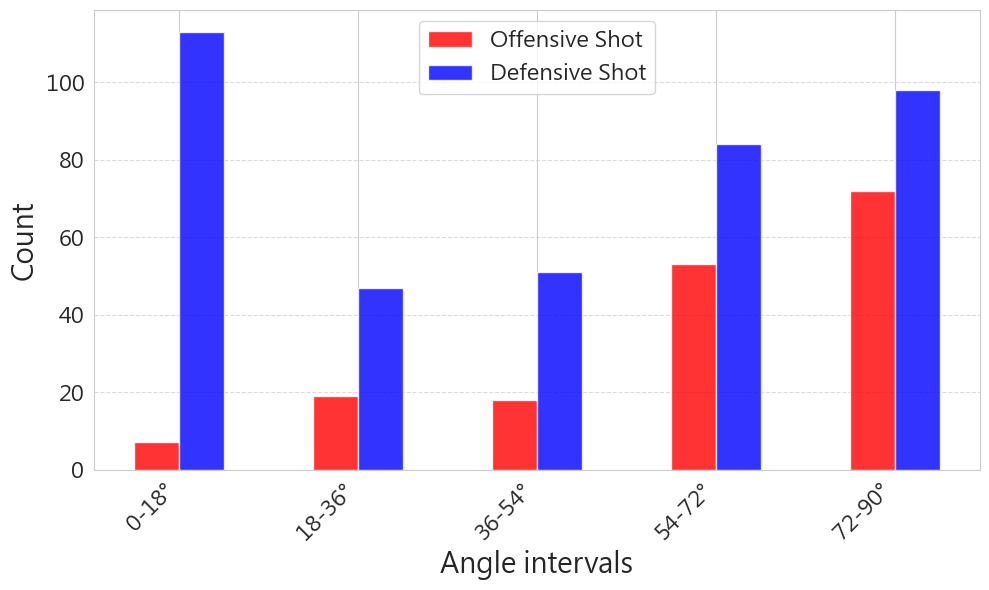

c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:349: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


Successfully loaded data, original event count: 630
Filtered Angle=-404.0 and invalid rows, final valid shot events: 562
Filtered BallType: ['發長球', '發短球', '未分類']

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Defensive Shot    0.33
Offensive Shot    0.35
Other Shot        0.33
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Zone
Backcourt    0.20
Forecourt    0.09
Midcourt     0.71
Name: Count, dtype: float64
--------------------



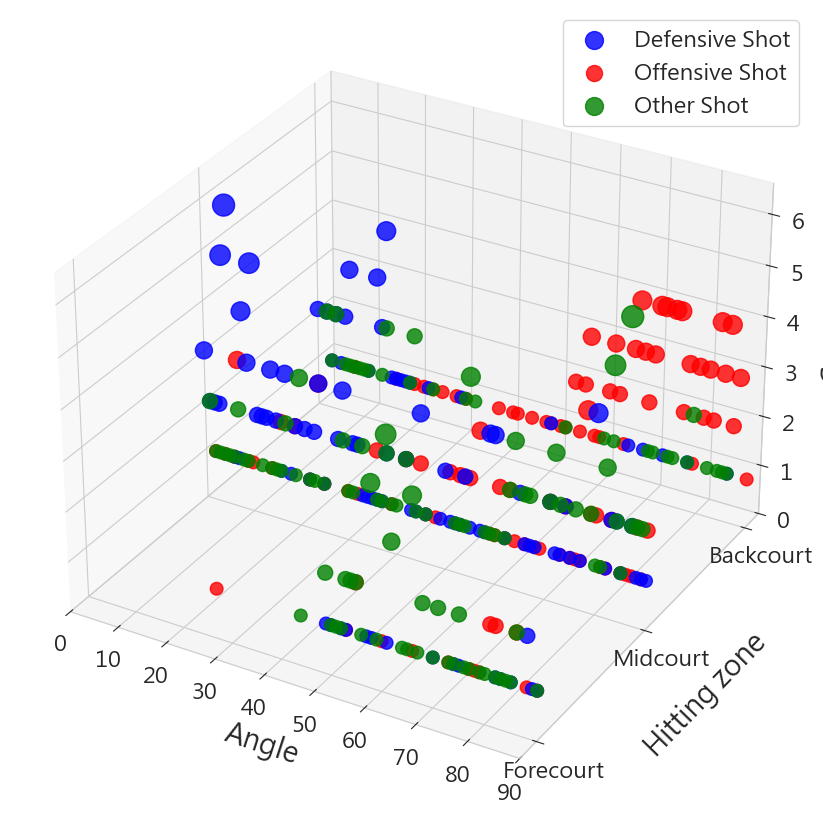

c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:363: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df_agg.groupby(['Angle_Group', 'ShotType'])['Count'].sum().unstack(fill_value=0)


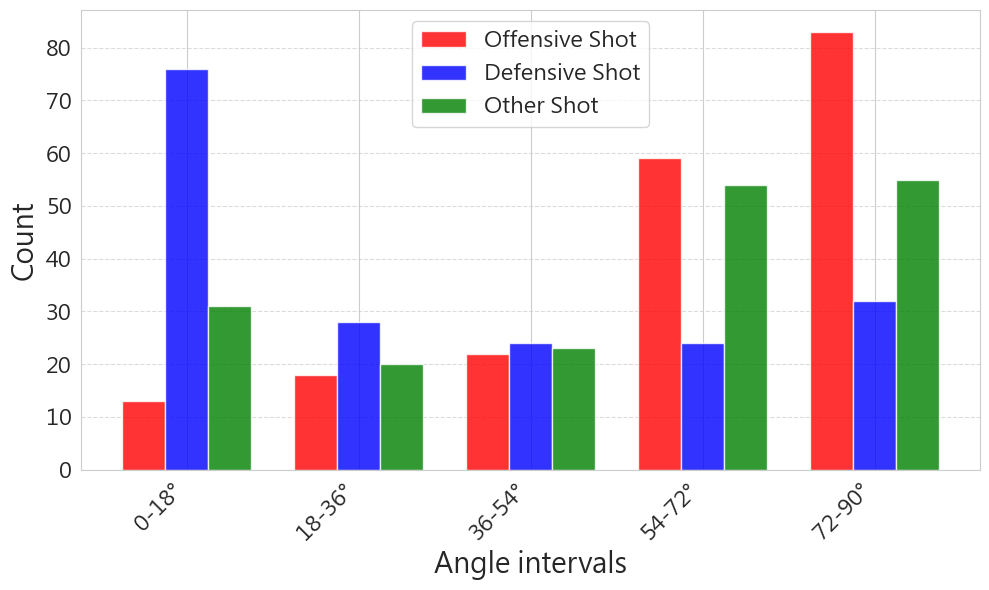

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
from src.analysis.general_analyze import plot_badminton_shot_analysis, plot_badminton_up_down_analysis, analyze_badminton_rally_stats,  analyze_badminton_shot_distribution


plot_badminton_shot_analysis(full_df)
plot_badminton_up_down_analysis(full_df)

In [11]:
analyze_badminton_rally_stats(full_df)
analyze_badminton_shot_distribution(full_df)

=== Badminton Rally/Shot Statistics ===
event_name  total_rallies  total_shots  average_shots_per_rally  max_shots  min_shots
        MD             67          630                      9.4         47          1
----------------------------------------
Total Rallies: 67
Total Shots: 630
Average Shots per Rally: 9.40

--- Final Analysis Report [Count (Percentage)] ---
                       MD         Total
Drop           25 (3.97%)    25 (3.97%)
Long Serve      2 (0.32%)     2 (0.32%)
Short Serve   65 (10.32%)   65 (10.32%)
Drive         99 (15.71%)   99 (15.71%)
Lob          111 (17.62%)  111 (17.62%)
Push/Rush     74 (11.75%)   74 (11.75%)
Smash         70 (11.11%)   70 (11.11%)
Net Shot     182 (28.89%)  182 (28.89%)
Clear           2 (0.32%)     2 (0.32%)
Total                 630           630
----------------------------------------


,MD,Total
Drop,25 (3.97%),25 (3.97%)
Long Serve,2 (0.32%),2 (0.32%)
Short Serve,65 (10.32%),65 (10.32%)
Drive,99 (15.71%),99 (15.71%)
Lob,111 (17.62%),111 (17.62%)
Push/Rush,74 (11.75%),74 (11.75%)
Smash,70 (11.11%),70 (11.11%)
Net Shot,182 (28.89%),182 (28.89%)
Clear,2 (0.32%),2 (0.32%)
Total,630,630


c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\cce_analysis.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_data[cover_col_name] = valid_data[cover_col_name].astype(bool)


分析中: 共 378 筆 Attack 陣型下的擊球數據。

--- Reaction-Cover ---
                   total_attempts  total_failures  failure_rate  success_rate
is_reaction_cover                                                            
True                          324              34     10.493827     89.506173
False                          16               6     37.500000     62.500000

[卡方檢定與效應量]
Chi-square: 8.27
p-value: 0.00403

--- (Chi-Square Test) ---
p-value: 0.00403


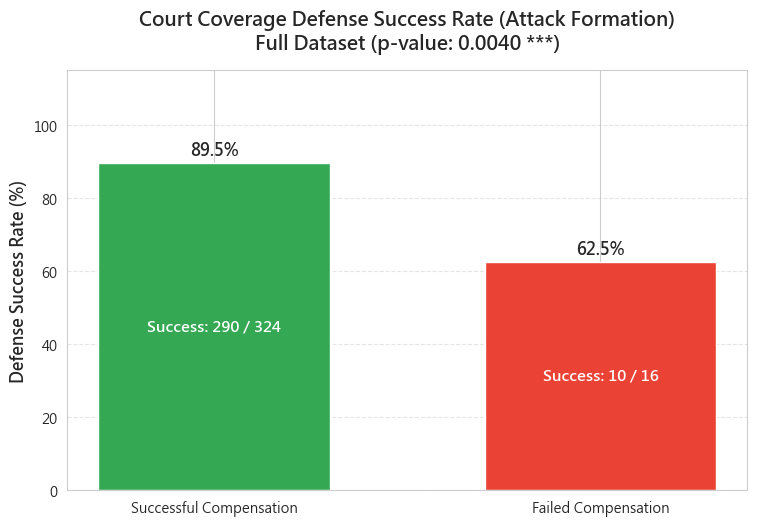

In [12]:
from src.analysis.cce_analysis import global_cce_analysis
global_cce_analysis(full_df, event_type=None
                         , selected_type=['對手落地致勝','未過網','掛網','出界'], shot_to_end=[1,2,3])

In [13]:
from src.analysis.tlai_analysis import analyze_defense_aai
analyze_defense_aai(full_df, threat_shot_types = ['殺球', '切球'])

 There are 95 valid records for defense analysis.

[Logistic Regression Analysis for Nonlinear TLAI Effect]
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.9478      0.808     -2.411      0.016      -3.531      -0.364
AAI_scaled_10x     1.2345      1.295      0.953      0.341      -1.304       3.773
AAI_squared       -0.5222      0.432     -1.210      0.226      -1.368       0.324

>> Coefficient for quadratic term (AAI_squared) : -0.5222
>> P-value: 0.22644

[TLAI threshold analysis (only showing intervals with sample size >= 100)]
Empty DataFrame
Columns: [AAI_bin, Failure_Rate, Sample_Count]
Index: []


,AAI_bin,Failure_Rate,Sample_Count
0,0.00,10.526316,19
1,0.05,30.000000,20
2,0.10,23.076923,13
3,0.15,0.000000,10
4,0.20,20.000000,15
5,0.25,16.666667,6
6,0.30,0.000000,5
7,0.35,0.000000,5
8,0.40,0.000000,1
9,0.45,NaN,0


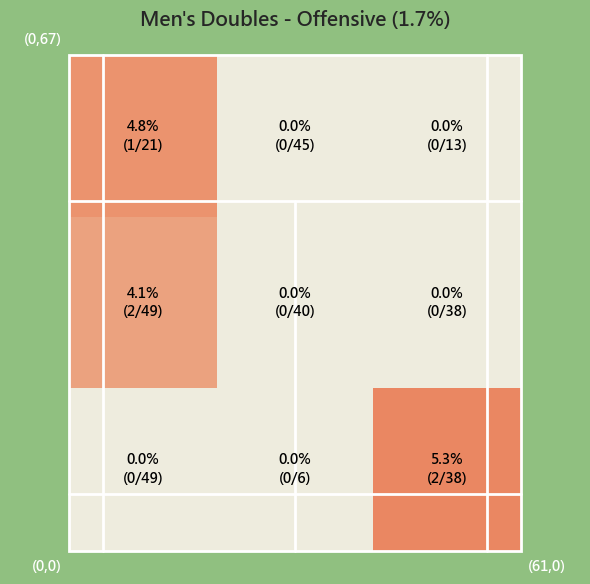

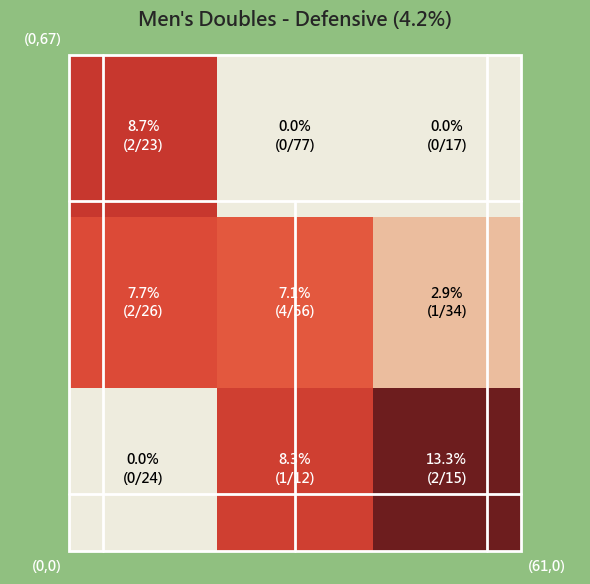

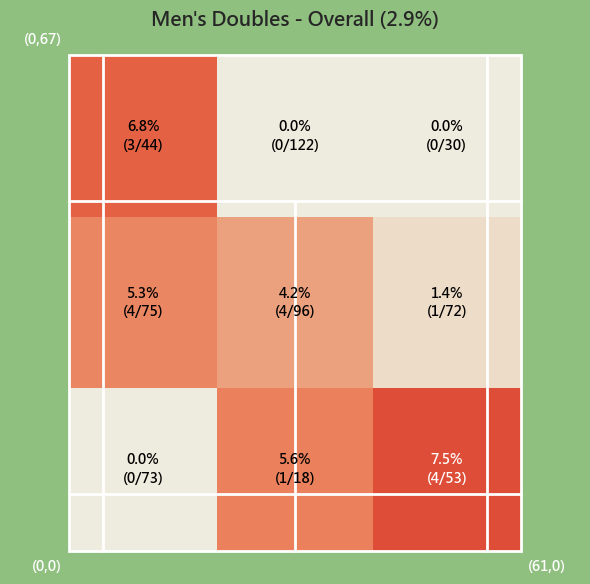

無符合條件的數據。


In [14]:
from src.analysis.defensive_failure import analyze_defensive_failure_rate
analyze_defensive_failure_rate(full_df, event_type=1)
analyze_defensive_failure_rate(full_df, event_type=2)

An error occurred: [Errno 2] No such file or directory: './img/matches/intensity_analysis.png'


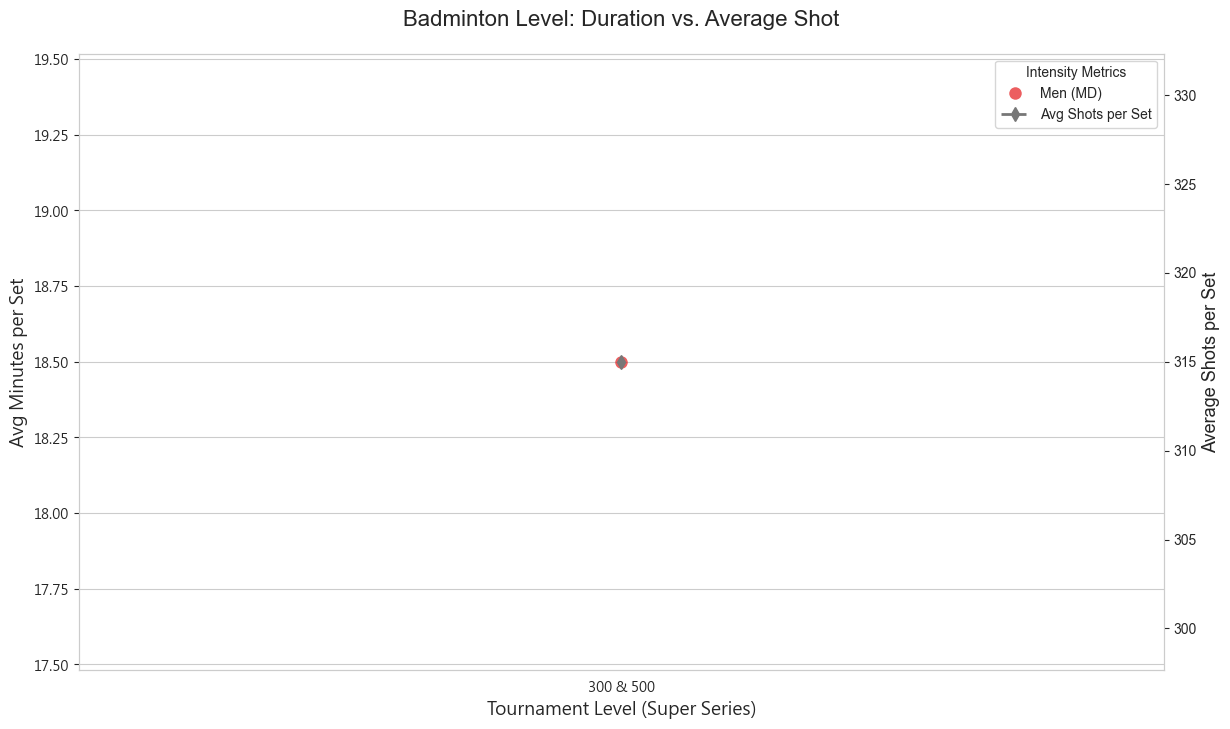

In [15]:
from src.analysis.matches_analyze import plot_badminton_intensity

match_tour_data = pd.merge(
        left=match_data,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )
plot_badminton_intensity(match_tour_data,df_match_rally_shot)